In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import grangercausalitytests
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/delhi_2019_all_stations.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Season'] = df['Timestamp'].dt.month.map({
    12:'Winter',1:'Winter',2:'Winter',
    3:'Summer',4:'Summer',5:'Summer',
    6:'Monsoon',7:'Monsoon',8:'Monsoon',9:'Monsoon',
    10:'Post-Monsoon',11:'Post-Monsoon'
})

# Use Patparganj — best overall data quality
station = 'Patparganj'
df_st = df[df['Station']==station].copy()

# FIX: Added numeric_only=True so pandas ignores the string columns!
df_st = df_st.set_index('Timestamp').resample('1H').mean(numeric_only=True)
df_st = df_st.ffill().bfill()

# Variables for causal analysis
causal_vars = ['PM25','NO2','CO','Ozone','SO2','AT','RH','WS','SR','BP']
df_causal = df_st[causal_vars].dropna()

print("Shape:", df_causal.shape)
print("Date range:", df_causal.index.min(), "→", df_causal.index.max())
print("\nMissing values:", df_causal.isnull().sum().sum())
df_causal.head(3)


Shape: (8760, 10)
Date range: 2019-01-01 00:00:00 → 2019-12-31 23:00:00

Missing values: 0


,PM25,NO2,CO,Ozone,SO2,AT,RH,WS,SR,BP
Timestamp,,,,,,,,,,
2019-01-01 00:00:00,458.25,28.950,4.975,0.475,4.250,10.350,81.075,0.450,3.175,997.375
2019-01-01 01:00:00,472.25,29.525,4.500,2.100,4.175,9.675,84.650,0.325,3.150,997.275
2019-01-01 02:00:00,440.50,29.800,4.300,0.400,4.175,9.600,84.700,0.625,3.025,997.075


In [2]:
# Test which variables Granger-cause PM2.5
target = 'PM25'
predictors = ['AT', 'RH', 'WS', 'SR', 'BP', 'NO2', 'CO', 'SO2', 'Ozone']
max_lag = 8  # test up to 8 hour lags

print("=" * 65)
print(f"GRANGER CAUSALITY TESTS → Target: {target}")
print(f"Station: {station} | Max lag: {max_lag} hours")
print("=" * 65)

granger_results = []

for predictor in predictors:
    try:
        test_data = df_causal[[target, predictor]].dropna()
        result = grangercausalitytests(test_data, maxlag=max_lag, verbose=False)
        
        # Find best lag (minimum p-value)
        best_lag = min(result.keys(), 
                      key=lambda k: result[k][0]['ssr_ftest'][1])
        best_p = result[best_lag][0]['ssr_ftest'][1]
        best_f = result[best_lag][0]['ssr_ftest'][0]
        
        significant = "✓ YES" if best_p < 0.05 else "✗ NO"
        granger_results.append({
            'Predictor': predictor,
            'Best_Lag_hrs': best_lag,
            'F_statistic': round(best_f, 3),
            'p_value': round(best_p, 6),
            'Granger_Causes_PM25': significant
        })
        print(f"{predictor:10} → PM25 | Best lag: {best_lag}h | "
              f"F={best_f:.2f} | p={best_p:.4f} | {significant}")
    except Exception as e:
        print(f"{predictor}: ERROR - {e}")

granger_df = pd.DataFrame(granger_results)
granger_df.to_csv('../figures/21_granger_results.csv', index=False)
print("\nSaved!")

GRANGER CAUSALITY TESTS → Target: PM25
Station: Patparganj | Max lag: 8 hours
AT         → PM25 | Best lag: 4h | F=109.98 | p=0.0000 | ✓ YES
RH         → PM25 | Best lag: 5h | F=93.70 | p=0.0000 | ✓ YES
WS         → PM25 | Best lag: 8h | F=19.38 | p=0.0000 | ✓ YES
SR         → PM25 | Best lag: 1h | F=394.90 | p=0.0000 | ✓ YES
BP         → PM25 | Best lag: 7h | F=36.70 | p=0.0000 | ✓ YES
NO2        → PM25 | Best lag: 3h | F=125.94 | p=0.0000 | ✓ YES
CO         → PM25 | Best lag: 3h | F=427.49 | p=0.0000 | ✓ YES
SO2        → PM25 | Best lag: 5h | F=39.22 | p=0.0000 | ✓ YES
Ozone      → PM25 | Best lag: 5h | F=39.60 | p=0.0000 | ✓ YES

Saved!


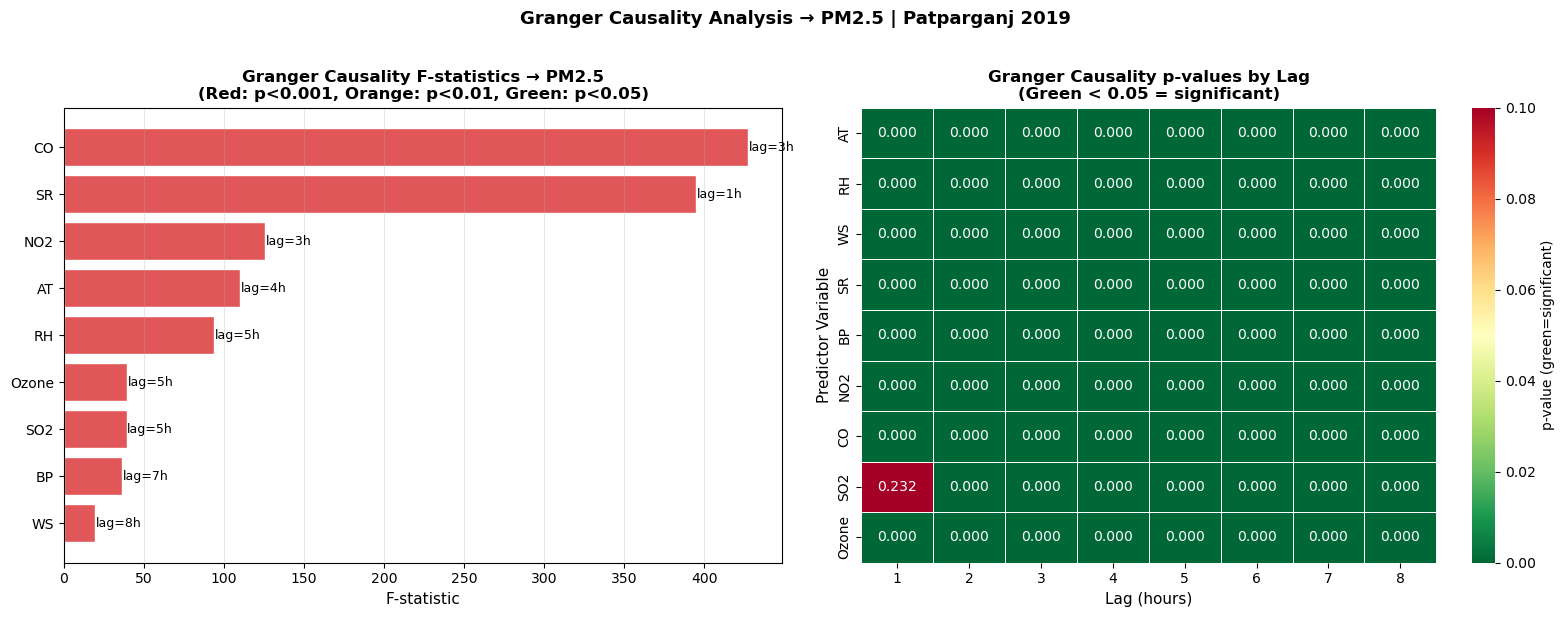

Saved!


In [3]:
# Plot F-statistics for significant relationships
sig_results = granger_df[granger_df['p_value'] < 0.05].sort_values('F_statistic', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# F-statistic bar chart
colors = ['#e15759' if p < 0.001 else '#f28e2b' if p < 0.01 else '#59a14f' 
          for p in sig_results['p_value']]
axes[0].barh(sig_results['Predictor'], sig_results['F_statistic'],
             color=colors, edgecolor='white')
axes[0].set_xlabel('F-statistic', fontsize=11)
axes[0].set_title('Granger Causality F-statistics → PM2.5\n(Red: p<0.001, Orange: p<0.01, Green: p<0.05)',
                  fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')
for i, (_, row) in enumerate(sig_results.iterrows()):
    axes[0].text(row['F_statistic'] + 0.5, i, 
                f"lag={row['Best_Lag_hrs']}h", va='center', fontsize=9)

# Lag heatmap — p-values across all lags
lag_matrix = pd.DataFrame(index=predictors, columns=range(1, max_lag+1), dtype=float)
for predictor in predictors:
    try:
        test_data = df_causal[[target, predictor]].dropna()
        result = grangercausalitytests(test_data, maxlag=max_lag, verbose=False)
        for lag in range(1, max_lag+1):
            lag_matrix.loc[predictor, lag] = result[lag][0]['ssr_ftest'][1]
    except:
        pass

lag_matrix = lag_matrix.astype(float)
sns.heatmap(lag_matrix, annot=True, fmt='.3f', cmap='RdYlGn_r',
            ax=axes[1], vmin=0, vmax=0.1,
            cbar_kws={'label': 'p-value (green=significant)'},
            linewidths=0.5)
axes[1].set_xlabel('Lag (hours)', fontsize=11)
axes[1].set_ylabel('Predictor Variable', fontsize=11)
axes[1].set_title('Granger Causality p-values by Lag\n(Green < 0.05 = significant)',
                  fontweight='bold')

plt.suptitle(f'Granger Causality Analysis → PM2.5 | {station} 2019',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/21_granger_causality.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

Running seasonal Granger causality tests...

Winter: 2160 hourly observations
Summer: 2208 hourly observations
Monsoon: 2928 hourly observations
Post-Monsoon: 1464 hourly observations

=== SEASONAL GRANGER CAUSALITY p-values ===
     Winter  Summer  Monsoon  Post-Monsoon
WS      0.0     0.0   0.0000           0.0
RH      0.0     0.0   0.0001           0.0
AT      0.0     0.0   0.0000           0.0
SR      0.0     0.0   0.0001           0.0
NO2     0.0     0.0   0.0000           0.0


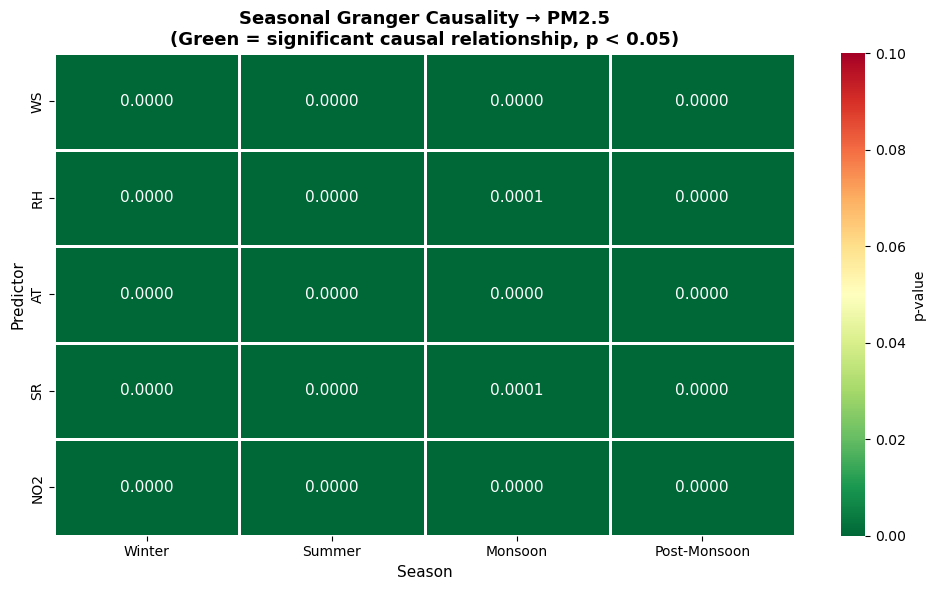

Saved!


In [4]:
# Run Granger on each season separately — does causal structure change?
seasons = ['Winter', 'Summer', 'Monsoon', 'Post-Monsoon']
key_predictors = ['WS', 'RH', 'AT', 'SR', 'NO2']

seasonal_granger = pd.DataFrame(index=key_predictors, columns=seasons, dtype=float)

df_st_season = df_st.copy()
df_st_season['Season'] = df_st_season.index.month.map({
    12:'Winter',1:'Winter',2:'Winter',
    3:'Summer',4:'Summer',5:'Summer',
    6:'Monsoon',7:'Monsoon',8:'Monsoon',9:'Monsoon',
    10:'Post-Monsoon',11:'Post-Monsoon'
})

print("Running seasonal Granger causality tests...\n")
for season in seasons:
    df_seas = df_st_season[df_st_season['Season']==season][causal_vars].dropna()
    print(f"{season}: {len(df_seas)} hourly observations")
    
    for predictor in key_predictors:
        try:
            test_data = df_seas[['PM25', predictor]].dropna()
            if len(test_data) < 50:
                seasonal_granger.loc[predictor, season] = np.nan
                continue
            result = grangercausalitytests(test_data, maxlag=6, verbose=False)
            best_p = min(result[k][0]['ssr_ftest'][1] for k in result.keys())
            seasonal_granger.loc[predictor, season] = round(best_p, 4)
        except:
            seasonal_granger.loc[predictor, season] = np.nan

print("\n=== SEASONAL GRANGER CAUSALITY p-values ===")
print(seasonal_granger.to_string())

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
seasonal_granger_float = seasonal_granger.astype(float)
sns.heatmap(seasonal_granger_float, annot=True, fmt='.4f',
            cmap='RdYlGn_r', ax=ax, vmin=0, vmax=0.1,
            linewidths=1, cbar_kws={'label': 'p-value'},
            annot_kws={'size': 11})
ax.set_title('Seasonal Granger Causality → PM2.5\n(Green = significant causal relationship, p < 0.05)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Season', fontsize=11)
ax.set_ylabel('Predictor', fontsize=11)
plt.tight_layout()
plt.savefig('../figures/22_seasonal_granger.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [7]:

!pip install tigramite

from tigramite import data_processing as pp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr
import tigramite.plotting as tp

# Prepare data for PCMCI
pcmci_vars = ['PM25', 'NO2', 'CO', 'Ozone', 'AT', 'RH', 'WS', 'SR']
df_pcmci = df_causal[pcmci_vars].dropna()

# Standardize
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_pcmci.values)

# Create tigramite dataframe
dataframe = pp.DataFrame(
    data_scaled,
    datatime=np.arange(len(data_scaled)),
    var_names=pcmci_vars
)

print("PCMCI Input:")
print(f"  Variables: {pcmci_vars}")
print(f"  Observations: {len(data_scaled)}")
print(f"  Max lag to test: 24 hours")
print("\nRunning PCMCI+ with ParCorr independence test...")
print("This may take 2-3 minutes...\n")

# Run PCMCI
parcorr = ParCorr(significance='analytic')
pcmci = PCMCI(dataframe=dataframe, cond_ind_test=parcorr, verbosity=0)

results = pcmci.run_pcmci(
    tau_min=1,
    tau_max=24,
    pc_alpha=0.05
)

print("PCMCI complete!")
print(f"\nSignificant links found:")
p_matrix = results['p_matrix']
val_matrix = results['val_matrix']

sig_links = []
for i, target_var in enumerate(pcmci_vars):
    for j, source_var in enumerate(pcmci_vars):
        for lag in range(1, 25):
            if p_matrix[j, i, lag] < 0.05:
                sig_links.append({
                    'Source': source_var,
                    'Target': target_var,
                    'Lag_hrs': lag,
                    'Coefficient': round(val_matrix[j, i, lag], 3),
                    'p_value': round(p_matrix[j, i, lag], 4)
                })

sig_df = pd.DataFrame(sig_links)
pm25_links = sig_df[sig_df['Target']=='PM25'].sort_values('p_value')
print("\n=== CAUSAL LINKS TO PM2.5 ===")
print(pm25_links.to_string(index=False))
sig_df.to_csv('../figures/23_pcmci_results.csv', index=False)

SyntaxError: invalid syntax (<string>, line 1)

Causal graph saved!

=== KEY CAUSAL FINDINGS ===
PM25     → PM25 | lag=1h | coef=+0.787 | p=0.0000
PM25     → PM25 | lag=2h | coef=-0.283 | p=0.0000
PM25     → PM25 | lag=3h | coef=+0.056 | p=0.0000
RH       → PM25 | lag=1h | coef=+0.067 | p=0.0000
CO       → PM25 | lag=4h | coef=+0.054 | p=0.0000
CO       → PM25 | lag=3h | coef=+0.058 | p=0.0000
PM25     → PM25 | lag=20h | coef=+0.047 | p=0.0000
CO       → PM25 | lag=2h | coef=-0.209 | p=0.0000
NO2      → PM25 | lag=1h | coef=+0.070 | p=0.0000
NO2      → PM25 | lag=2h | coef=-0.058 | p=0.0000


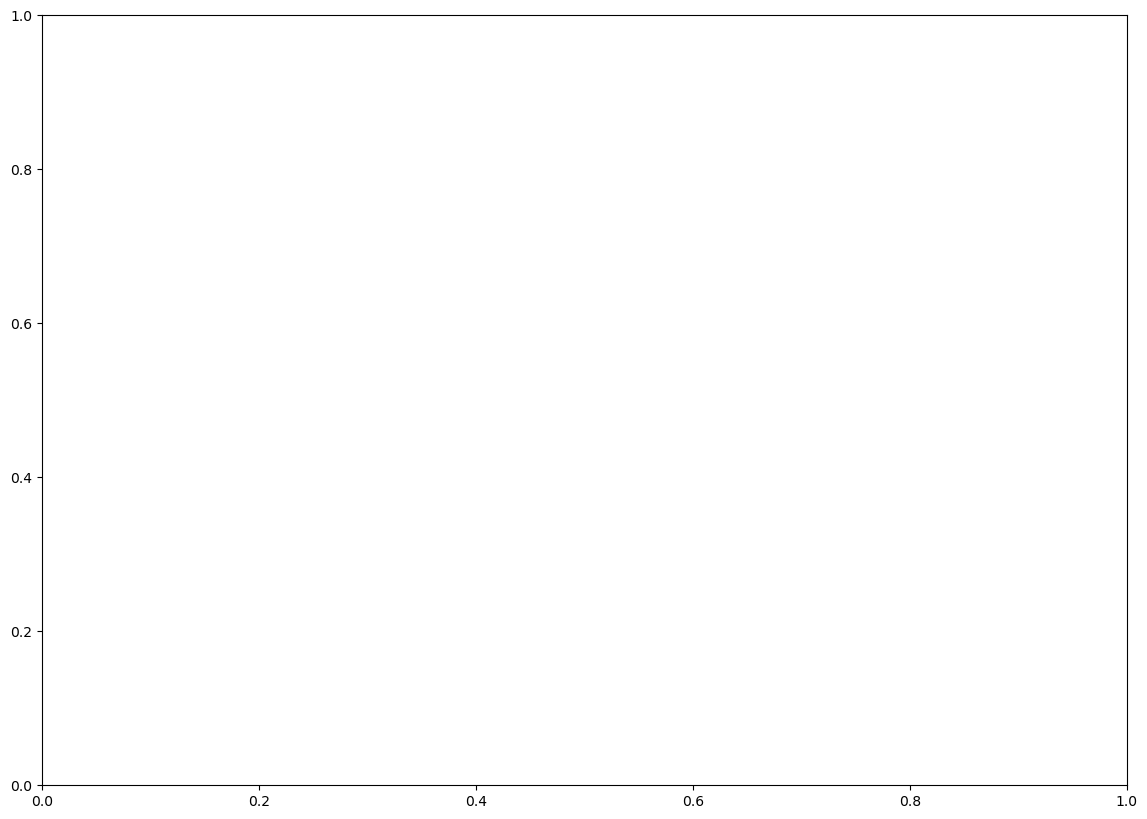

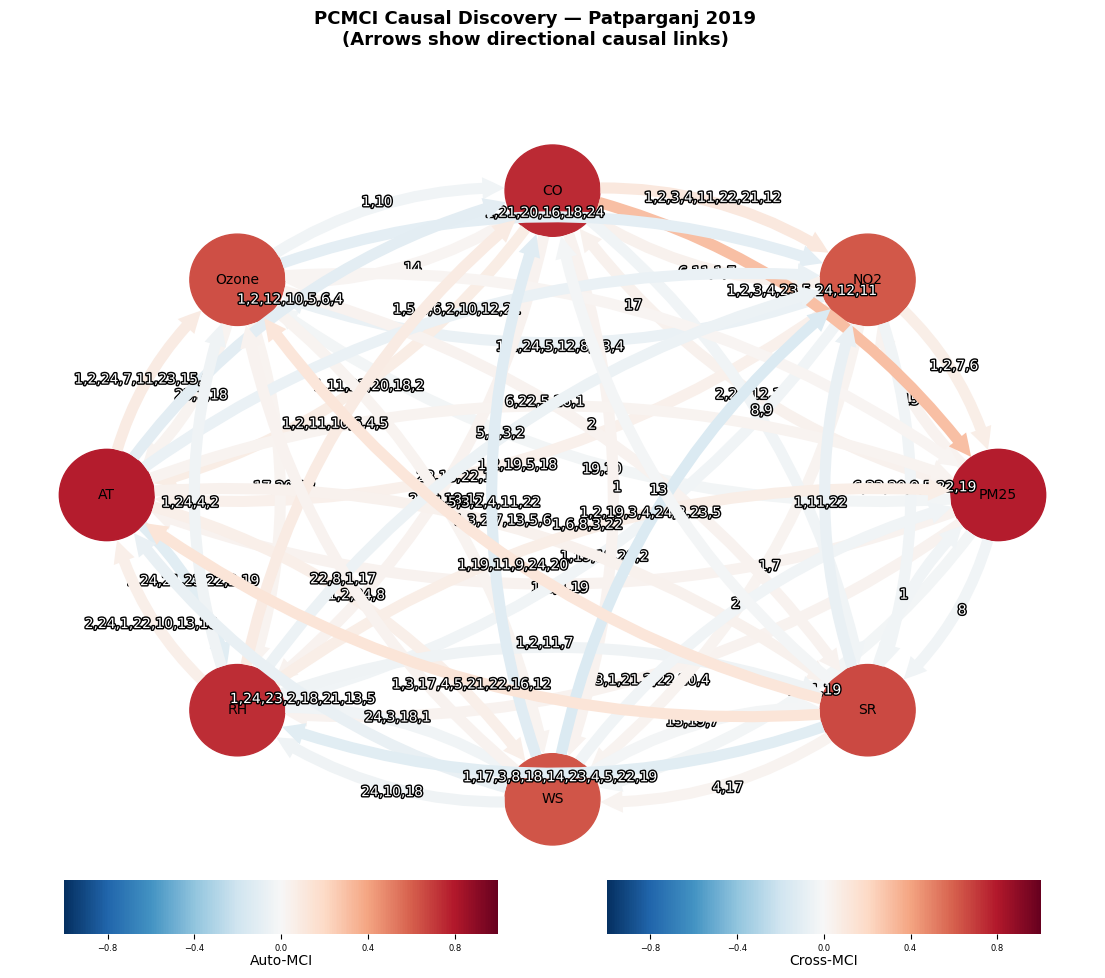

In [8]:
# Plot the causal graph
fig, ax = plt.subplots(figsize=(14, 10))

tp.plot_graph(
    val_matrix=results['val_matrix'],
    graph=results['graph'],
    var_names=pcmci_vars,
    link_colorbar_label='Cross-MCI',
    node_colorbar_label='Auto-MCI',
    figsize=(14, 10),
    save_name='../figures/23_pcmci_causal_graph.png',
    show_colorbar=True
)
plt.suptitle(f'PCMCI Causal Discovery — {station} 2019\n(Arrows show directional causal links)',
             fontsize=13, fontweight='bold')
print("Causal graph saved!")

# Also print summary
print("\n=== KEY CAUSAL FINDINGS ===")
for _, row in pm25_links.head(10).iterrows():
    print(f"{row['Source']:8} → PM25 | lag={row['Lag_hrs']}h | "
          f"coef={row['Coefficient']:+.3f} | p={row['p_value']:.4f}")